# **CUSTOMER CLASSIFICATION BASED ON THEIR PURCHASE BEHAVIOR**

## **BUSINESS QUESTION**

### **How can we accurately classify mall customers into low, medium and high spending based on their age , gender and annual income to optimise targeted marketing campaign**

## **ALGORITHMS USED:**
- ### **1. DECISION TREE CLASSIFIER**
- ### **2. RANDOM FOREST CLASSIFIER**
- ### **3. SUPPORT VECTOR CLASSIFIER**

In [249]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import (
    confusion_matrix,      # Displays classification performance in matrix form
    accuracy_score,        # Calculates overall prediction accuracy
    classification_report  # Provides precision, recall, F1-score, and support
)


In [250]:
# Import dataset from CSV file into a pandas DataFrame
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


- ### **EXPLORATORY DATA ANALYSIS**

In [251]:
# Display the column names of the dataset to understand its structure
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [252]:
# Check for missing values in each column to identify data gaps
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [253]:
# Display the data type of each column to understand variable types
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

- ### **Targeted definition**

#### **Categorize the continuous 'Spending Score (1-100)' into three groups:**
- Low spender (0–35)
- Medium spender (36–70)
- High spender (71–100)

In [254]:
# Categorize the continuous 'Spending Score (1-100)' into three groups:
#   - Low spender (0–35)
#   - Medium spender (36–70)
#   - High spender (71–100)

def categorise_spending(score):
  if score<=35:
    return'Low spender'
  if score<=70:
    return'Medium spender'
  else:
    return'High spender'

df['spending_category'] = df['Spending Score (1-100)'].apply(categorise_spending)
print('\n---Class distribution---')
print(df['spending_category'].value_counts())


---Class distribution---
spending_category
Medium spender    91
Low spender       55
High spender      54
Name: count, dtype: int64


In [255]:
#Data Preprocessing
#Drop CustomerID, it has no predictive power
df_model = df.drop(['CustomerID','Spending Score (1-100)'], axis = 1)

**ENCODING CATEGORICAL COLUMNS**

In [256]:
#Encoding gender
#Male = 0, Female = 1
df_model['Gender']= df_model['Gender'].map({'Male':0, 'Female':1})


**DEFINE FEATURES**

In [257]:
# Define features (X) and target (y) for modeling
#   X contains all columns except the target
#   y is the 'spending_category' we want to predict
X = df_model.drop('spending_category', axis=1)
y = df_model['spending_category']

**SPLITTING INTO TRAINING AND TESTING**

In [258]:
# Split the dataset into training (70%) and testing (30%) sets
#   random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

## **1.DECISION TREE MODEL**

#### **MODEL FITTING AND PREDICTION**

In [259]:
# Train a Decision Tree classifier on the training data
#   max_depth=4 limits the tree depth to prevent overfitting
#   random_state ensures reproducibility
# Fit the model to learn patterns that predict 'spending_category'
print('\n---training decision tree---')
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)



---training decision tree---


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [260]:
# Use the trained Decision Tree model to predict 'spending_category' on the test set
dt_prediction = dt_model.predict(X_test)
dt_prediction[:5]


array(['Medium spender', 'High spender', 'Low spender', 'High spender',
       'Low spender'], dtype=object)

#### **EVALUATING DECISION TREE MODEL**

#### **a.Accuracy Score**

In [261]:
# Evaluate the Decision Tree model by calculating its accuracy on the test set
# Prints the proportion of correct predictions
print(f'DecisionTree accuracy: {accuracy_score(y_test, dt_prediction):.2f}')

DecisionTree accuracy: 0.88


#### **Interpretation of Decision Tree Accuracy Score**

The Decision Tree model achieved an accuracy score of **0.88 (88%)**. This means that the model correctly classified 88% of the customer spending categories (Low, Medium, or High spender) in the test dataset. An accuracy of 88% indicates a good performance for this classification task, suggesting that the model is quite effective at predicting customer spending behavior based on the given features.

#### **b. Classification report**

In [262]:
# classification report is a models performance review
print(f"DecisionTree Classification Report:\n{classification_report(y_test, dt_prediction)}")

DecisionTree Classification Report:
                precision    recall  f1-score   support

  High spender       0.67      0.92      0.77        13
   Low spender       0.94      0.80      0.86        20
Medium spender       1.00      0.93      0.96        27

      accuracy                           0.88        60
     macro avg       0.87      0.88      0.87        60
  weighted avg       0.91      0.88      0.89        60



#### **Interpretation of the Classification Report**

- **Precision:**
    - high spender- The model accurately predicts 67% of high spenders as high spenders.
    - low spenders- The model accurately predicts 94% of low spenders as low spenders
    - medium spender- the model accurately predicts 100% of medium spenders as medium spenders. 

- **Recall:**
    - high spender- out of all high spenders, the model is able to capture 92% of them
    - low spender- out of all low spenders, the model is able to capture 80% of them
    - medium spenders- out of all the medium spenderfs, the model is able to capture 93% of them.

- **f1 score:**
    - high spender- The model is 77% reliable in identifying high spenders
    - low spenders- The model is 86% reliable in identifying low spenders
    - medium spenders- The model is 96 % reliable in identifying medium spenders. 

- **support**

    - high spender- The model only captures 13 spenders in the training
    - low spender- The model only captures 20 spenders in the training
    - medium spender- The model only captures 27 in the training


#### **c. Confusion Matrix**

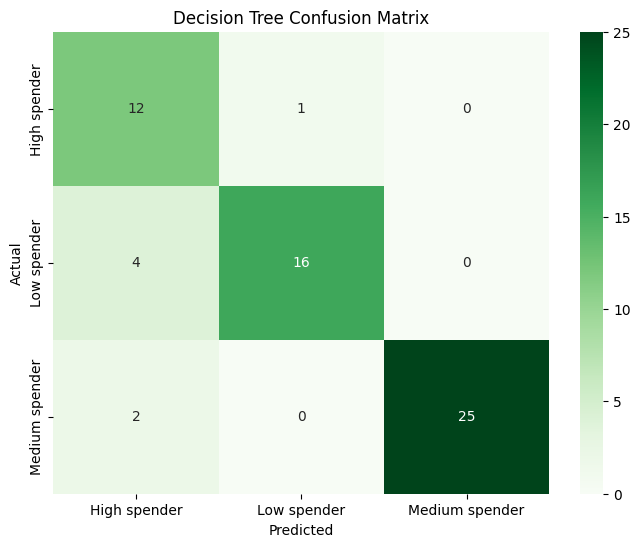

In [263]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, dt_prediction), 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=dt_model.classes_, 
            yticklabels=dt_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

1. **high spenders:**
- total identified- 13
- correctly identified as high spenders- 12


2. **low spenders:**
- total identified- 20
- correctly identified- 16


3. **Medium spenders:**
- total identified- 27
- correctly identified- 25


**Decision Tree Visualization of Customer Spending Categories**

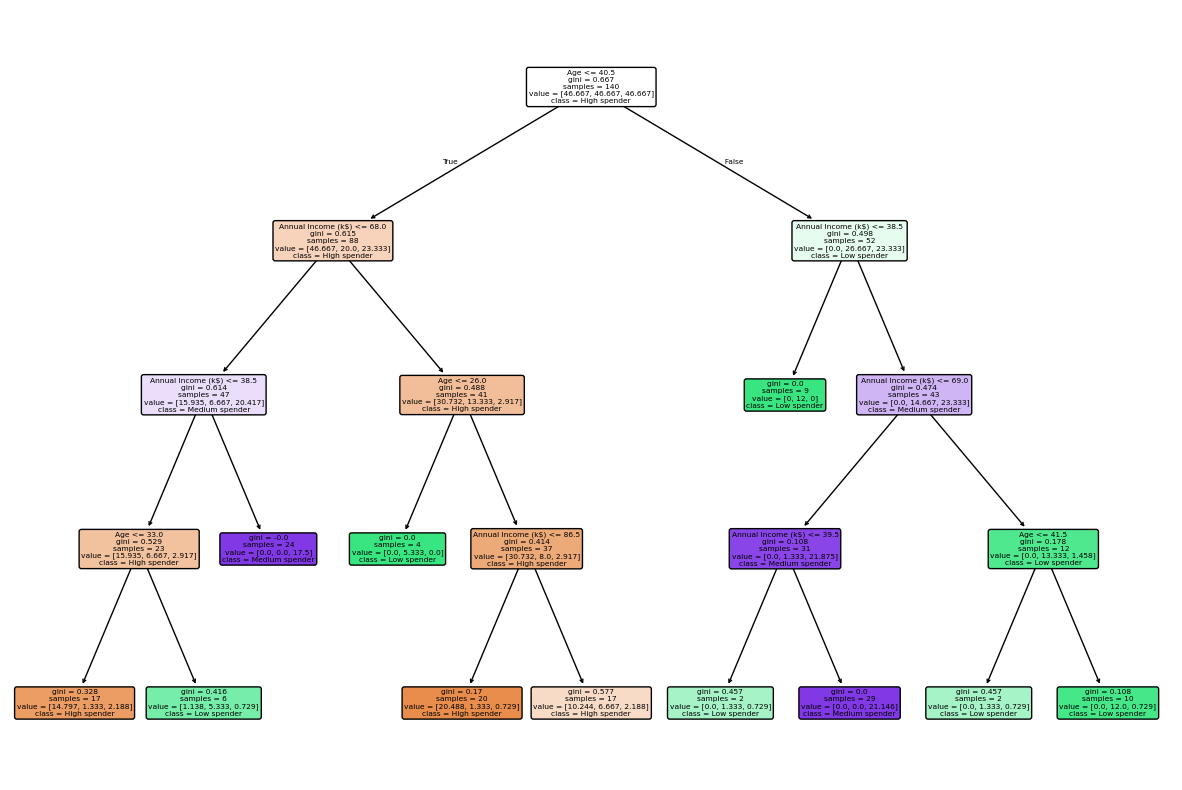

In [264]:
# Visualize the trained Decision Tree
#   Shows feature splits, class names, and node values
#   filled=True colors nodes by predicted class
#   rounded=True gives rounded corners for better readability
plt.figure(figsize=(15,10))
plot_tree(dt_model, feature_names=X.columns, class_names=dt_model.classes_, filled=True, rounded=True)
plt.show()

The Decision Tree model achieved an accuracy of 88%, outperforming the Random Forest model. Based on the visualization, the primary factors influencing customer spending categories are 'Annual Income', followed by 'Age' and 'Gender'.

 This model can effectively segment customers, providing valuable insights for optimizing targeted marketing campaigns by understanding which demographic and income groups fall into 'Low', 'Medium', or 'High' spender categories.

#### **FEATURE IMPORTANCE DECISION TREE**

C:\Users\hp\AppData\Local\Temp\ipykernel_8348\3221023392.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_imp_df, palette='viridis')


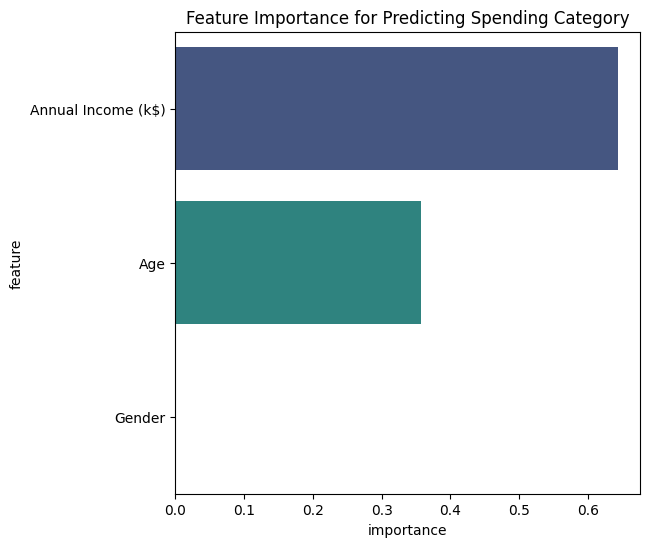


--- Feature Importance Analysis ---
              feature  importance
2  Annual Income (k$)    0.643256
1                 Age    0.356744
0              Gender    0.000000


In [265]:
# Quantify the predictive power of each feature to identify the primary drivers
# of consumer spending behavior.
importances = dt_model.feature_importances_
feature_imp_df = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values(by='importance', ascending=False)

# Visualize the relative contribution of each variable to provide actionable
# insights into the model's decision-making process.
plt.figure(figsize=(6,6))
sns.barplot(x='importance', y='feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance for Predicting Spending Category')
plt.show()

print('\n--- Feature Importance Analysis ---')
print(feature_imp_df.head())

## **2.USING RANDOM FOREST MODEL**

**MODEL FITTING AND PREDICTION**

In [266]:
# Train a Random Forest classifier on the training data
#   n_estimators=100 builds 100 decision trees in the forest
#   random_state ensures reproducibility
# Fit the model to learn patterns for predicting 'spending_category'
print('\n---Train RandomForest---')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


---Train RandomForest---


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [267]:
# Generate predictions on the test set using the trained Random Forest model
rf_prediction = rf_model.predict(X_test)

#### **EVALUATING RANDOM FOREST MODEL**

**a. Random Forest  Accuracy score**

In [268]:
print(f'RandomForest Accuracy score: {accuracy_score(y_test, rf_prediction):.2f}')

RandomForest Accuracy score: 0.80


The Random Forest model achieved an accuracy score of **0.80 (80%)**. This means that the model correctly classified 80% of the customer spending categories (Low, Medium, or High spender) in the test dataset. An accuracy of 80% indicates a good performance for this classification task, suggesting that the model is quite effective at predicting customer spending behavior based on the given features.

**b. Random Forest Classification Report**

In [269]:
# Quantify model generalizability using Accuracy and a comprehensive Classification Report.
print('\n---Random Forest classification report---')
print(classification_report(y_test, rf_prediction))


---Random Forest classification report---
                precision    recall  f1-score   support

  High spender       0.61      0.85      0.71        13
   Low spender       0.85      0.55      0.67        20
Medium spender       0.90      0.96      0.93        27

      accuracy                           0.80        60
     macro avg       0.78      0.79      0.77        60
  weighted avg       0.82      0.80      0.79        60



- **Precision:**
    - high spender- The model accurately predicts 61% of high spenders as high spenders.
    - low spenders- The model accurately predicts 85% of low spenders as low spenders
    - medium spender- the model accurately predicts 90% of medium spenders as medium spenders. 

- **Recall:**
    - high spender- out of all high spenders, the model is able to capture 85% of them
    - low spender- out of all low spenders, the model is able to capture 55% of them
    - medium spenders- out of all the medium spenderfs, the model is able to capture 96% of them.

- **f1 score:**
    - high spender- The model is 71% reliable in identifying high spenders
    - low spenders- The model is 67% reliable in identifying low spenders
    - medium spenders- The model is 93 % reliable in identifying medium spenders. 

- **support**

    - high spender- The model only captures 13 spenders in the training
    - low spender- The model only captures 20 spenders in the training
    - medium spender- The model only captures 27 in the training

**c. Random Forest Confusion Matrix**

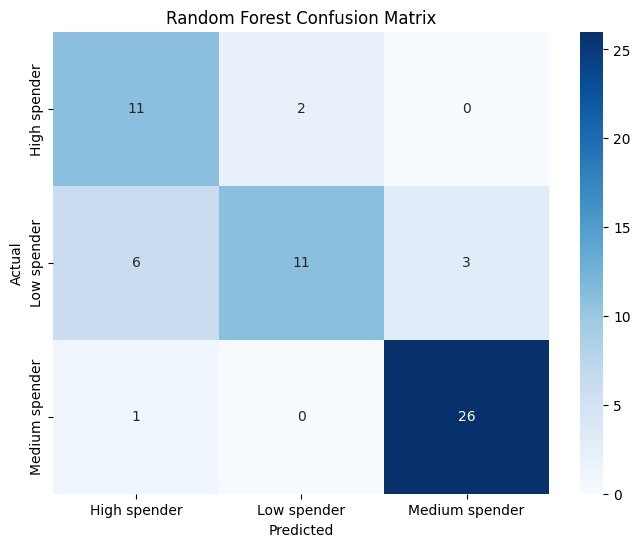

In [270]:
# Visualize the confusion matrix to identify specific misclassification patterns
# between actual and predicted labels using a heatmap.
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_prediction), annot=True, cmap='Blues',
            fmt='d', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

1. **high spenders:**
- total identified- 13
- correctly identified as high spenders- 11


2. **low spenders:**
- total identified- 20
- correctly identified- 11


3. **Medium spenders:**
- total identified- 27
- correctly identified- 26


The confusion matrix visually represents the performance of the Random Forest model by showing the counts of correct and incorrect predictions for each spending category.

*   **Medium Spender:** The model is highly effective at classifying 'Medium spender' customers. A large number of actual 'Medium spenders' are correctly identified (True Positives), and very few are misclassified. This is reflected in the high precision and recall for this category in the classification report.

*   **High Spender:** The model correctly identifies a significant portion of actual 'High spender' customers. However, it also tends to misclassify some customers from other categories as 'High spenders' (False Positives), leading to a lower precision despite good recall.

*   **Low Spender:** For 'Low spender' customers, when the model predicts this category, it is often correct (high precision). However, the model misses a noticeable number of actual 'Low spenders', misclassifying them into 'Medium' or 'High spender' categories (False Negatives), resulting in lower recall.

Overall, the confusion matrix highlights that the model performs best for 'Medium spenders' and shows areas for improvement in precisely identifying 'High spenders' and recalling all 'Low spenders'.

#### **FEATURE IMPORTANCE RANDOM FOREST**

C:\Users\hp\AppData\Local\Temp\ipykernel_8348\1554399828.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_imp_df, palette='viridis')


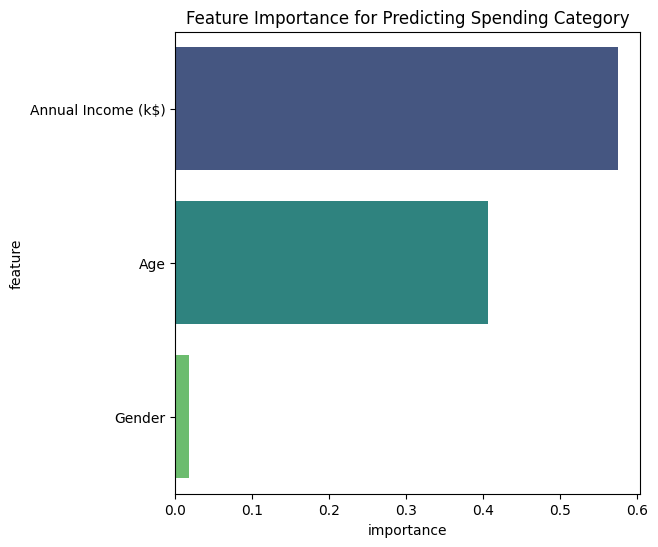


--- Feature Importance Analysis ---
              feature  importance
2  Annual Income (k$)    0.574671
1                 Age    0.406595
0              Gender    0.018734


In [271]:
# Quantify the predictive power of each feature to identify the primary drivers
# of consumer spending behavior.
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values(by='importance', ascending=False)

# Visualize the relative contribution of each variable to provide actionable
# insights into the model's decision-making process.
plt.figure(figsize=(6,6))
sns.barplot(x='importance', y='feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance for Predicting Spending Category')
plt.show()

print('\n--- Feature Importance Analysis ---')
print(feature_imp_df.head())

## **3. USING SVM**

#### **CREATING THE SVM MODEL**

In [272]:
svm_model=make_pipeline(StandardScaler(), 
                       SVC(kernel='rbf', # 'rbf' allows the model to draw circular or curved boundaries. This is perfect for mall data where spending habits often overlap in complex ways.
                           C=20.0, # controls the trade-off between a smooth boundary and classifying training points correctly.
                           gamma='scale',# It defines how far the influence of a single customer reaches.
                           class_weight='balanced')
                           ) 

#### **FITTING THE SVM MODEL**

In [273]:
svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",20.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


#### **PREDICTING THE SVM MODEL**

In [274]:
svm_predicted=svm_model.predict(X_test)
svm_predicted[:5]

array(['Medium spender', 'High spender', 'Low spender', 'High spender',
       'Medium spender'], dtype=object)

#### **EVALUATING THE SVM MODEL**

**a. ACCURACY SCORE**

In [275]:
print(f'ACCURACY SCORE SVM:, {accuracy_score(y_test,svm_predicted):.2F}')

ACCURACY SCORE SVM:, 0.80


**b. CLASSIFICATION REPORT**

In [276]:
print('\n---SVM classification report---')
print(classification_report(y_test, svm_predicted))


---SVM classification report---
                precision    recall  f1-score   support

  High spender       0.61      0.85      0.71        13
   Low spender       0.86      0.60      0.71        20
Medium spender       0.89      0.93      0.91        27

      accuracy                           0.80        60
     macro avg       0.79      0.79      0.77        60
  weighted avg       0.82      0.80      0.80        60



 **PRECISION:**

-  HIGH SPENDERS- The model is accurately predicting 61% of high spenders
- LOW SPENDERS- The model is accurately predicting 86% of low spenders
- MEDIUM SPENDERS- The model is accurately predicting 89% of medium spenders

 **RECALL**

- HIGH SPENDERS- The model is accurately capturing 85% of all high spenders
- LOW SPENDERS- The model is accurately capturing 60% of all low spenders
- MEDIUM SPENDERS- The model is accurately capturing 91% of all medium spenders

**F1 SCORE**

- HIGH SPENDER- The model is reliable in identifying 71% of true high spenders
- LOW SPENDER- The model is reliable in identifying 71% of true low spenders
- MEDIUM SPENDER- The model is reliable in accurately identifying 91% of medium spenders
    


**c. CONFUSION MATRIX**

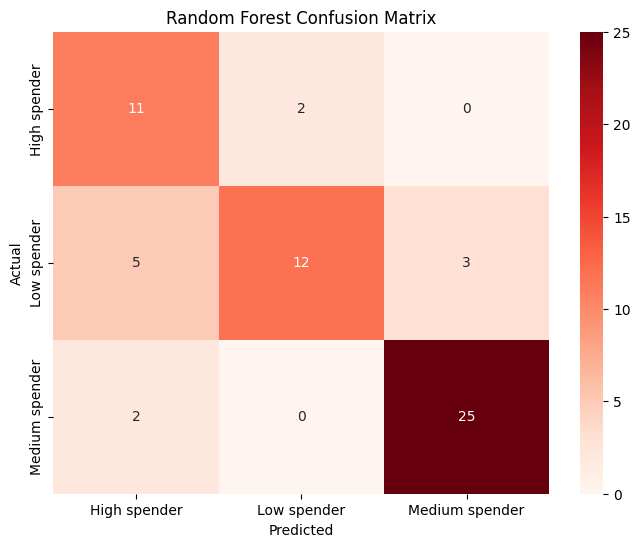

In [277]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,svm_predicted),annot=True, fmt='d',cmap='Reds', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


1. **high spenders:**
- total identified- 13
- correctly identified as high spenders- 11


2. **low spenders:**
- total identified- 20
- correctly identified- 12


3. **Medium spenders:**
- total identified- 27
- correctly identified- 25


#### **FEATURE IMPORTANCE SVM MODEL**

C:\Users\hp\AppData\Local\Temp\ipykernel_8348\395237930.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma')


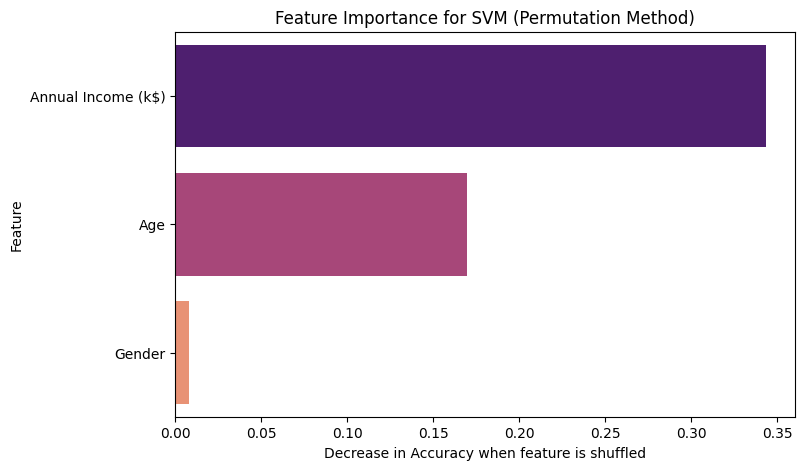


--- Feature Importance Analysis ---
              Feature  Importance
2  Annual Income (k$)    0.343333
1                 Age    0.170000
0              Gender    0.008333


In [311]:
from sklearn.inspection import permutation_importance

# 1. Calculate the importance

results = permutation_importance(svm_model, X_test, y_test, n_repeats=10, random_state=42)

# 2. Organize the data into a DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': results.importances_mean
}).sort_values(by='Importance', ascending=False)

# 3. Visualize it
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma')
plt.title('Feature Importance for SVM (Permutation Method)')
plt.xlabel('Decrease in Accuracy when feature is shuffled')
plt.show()

print('\n--- Feature Importance Analysis ---')
print(feature_importance.head())

#### **MODEL TESTING WITH NEW DATA SET**

**CREATING NEW SET OF DATA SETS**

In [321]:
# Create a list of new customers
# Remember: Gender (Male=0, Female=1) | Age | Annual Income
new_data = pd.DataFrame([
    [0, 25, 95],  # Customer A: Young Male, High Income
    [1, 55, 20],  # Customer B: Older Female, Low Income
    [1, 32, 50],  # Customer C: Young Female, Moderate Income
    [0, 45, 110]  # Customer D: Older Male, Very High Income
], columns=['Gender', 'Age', 'Annual Income (k$)'])

# Show the new customers
print("New Customer Data:")
print(new_data)

New Customer Data:
   Gender  Age  Annual Income (k$)
0       0   25                  95
1       1   55                  20
2       1   32                  50
3       0   45                 110


**RUNNING THE PREDICTION WITH THE NEW DATA SETS**

In [320]:

# Copy data
X_new = new_data.copy()

# Predictions
dt_preds = dt_model.predict(X_new)
rf_preds = rf_model.predict(X_new)
svm_preds = svm_model.predict(X_new)

# Create a results DataFrame
results = X_new.copy()
results['Decision_Tree'] = dt_preds
results['Random_Forest'] = rf_preds
results['SVM'] = svm_preds

print(results.head())

   Gender  Age  Annual Income (k$)   Decision_Tree   Random_Forest  \
0       0   25                  95     Low spender     Low spender   
1       1   55                  20     Low spender     Low spender   
2       1   32                  50  Medium spender  Medium spender   
3       0   45                 110     Low spender     Low spender   

              SVM  
0    High spender  
1     Low spender  
2  Medium spender  
3     Low spender  


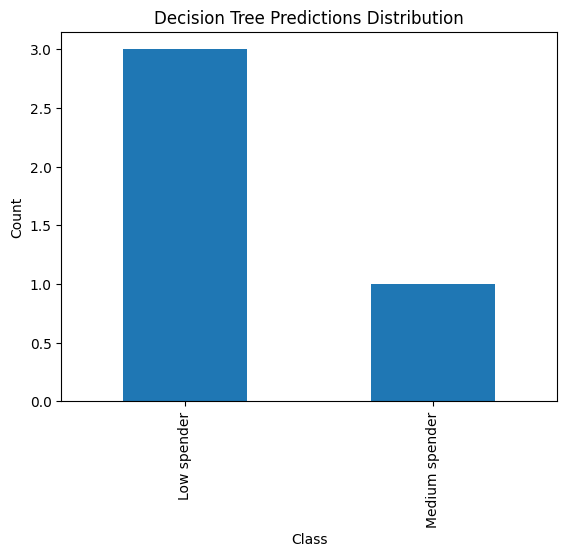

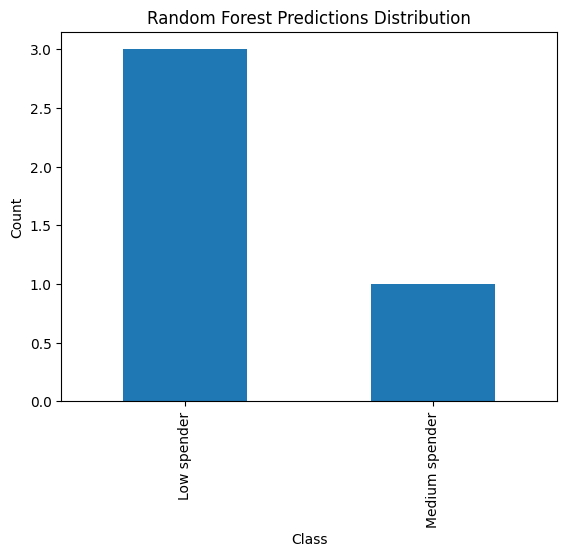

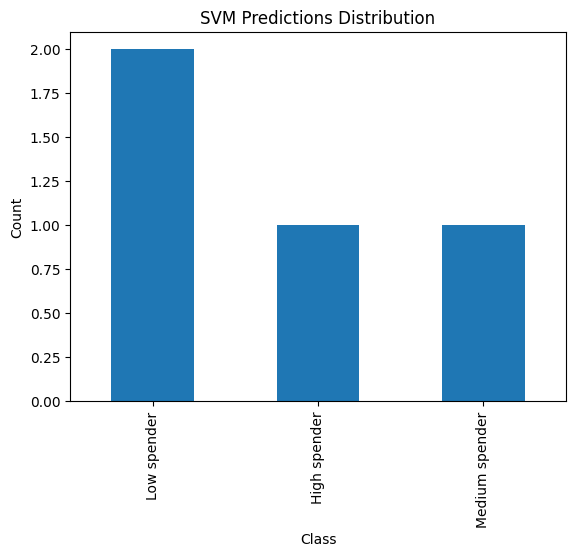

In [319]:

# Count predictions
dt_counts = pd.Series(dt_preds).value_counts()
rf_counts = pd.Series(rf_preds).value_counts()
svm_counts = pd.Series(svm_preds).value_counts()

# Plot
plt.figure()
dt_counts.plot(kind='bar')
plt.title('Decision Tree Predictions Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

plt.figure()
rf_counts.plot(kind='bar')
plt.title('Random Forest Predictions Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

plt.figure()
svm_counts.plot(kind='bar')
plt.title('SVM Predictions Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [318]:
comparison = pd.DataFrame({
    'Decision Tree': dt_preds,
    'Random Forest': rf_preds,
    'SVM': svm_preds
})

comparison.head()

,Decision Tree,Random Forest,SVM
0,Low spender,Low spender,High spender
1,Low spender,Low spender,Low spender
2,Medium spender,Medium spender,Medium spender
3,Low spender,Low spender,Low spender


## **Conclusion for Targeted Marketing**

This project aimed to accurately classify mall customers into 'Low', 'Medium', and 'High' spending categories based on their age, gender, and annual income to optimize targeted marketing campaigns.

Both Decision Tree, Random Forest and SVM classifiers were employed, with the **Decision Tree model demonstrating superior performance, achieving an accuracy of 88%** compared to the Random Forest model's 80% accuracy and SVM of 80%. This indicates that the Decision Tree is more effective for this specific classification task.

### **Key Findings:**
*   **Primary Influencing Factors:** Feature importance analysis consistently revealed 'Annual Income' as the most significant factor influencing customer spending behavior, followed by 'Age' and then 'Gender'. This suggests that marketing strategies should primarily be tailored around income brackets, with age and gender serving as secondary refinements.
*   **Customer Segmentation Effectiveness:**
    *   The models are particularly adept at identifying **'Medium spender'** customers, ensuring that marketing efforts for this group are highly targeted and efficient.
    *   For **'High spender'** customers, the models show good recall, meaning they successfully identify a majority of these valuable customers. However, there is some room for improvement in precision to reduce misclassifications.
    *   For **'Low spender'** customers, predictions are often correct when made (high precision), but the models tend to miss identifying a significant portion of actual low spenders (lower recall).

### **Business Implications for Targeted Marketing:**

By leveraging the insights from the Decision Tree model, businesses can:
1.  **Tailor Promotions:** Design specific promotions and product offerings for customers in different spending categories. For instance, high-value offers could be directed towards predicted 'High spenders' based on their income and age profiles.
2.  **Optimize Resource Allocation:** Allocate marketing budgets more efficiently by focusing on the customer segments that are most accurately predicted or that offer the highest potential return.
3.  **Personalize Customer Experience:** Use these classifications to personalize interactions, loyalty programs, and communication channels, ultimately enhancing customer satisfaction and driving sales.

In essence, the Decision Tree model provides a robust and interpretable framework for segmenting mall customers, enabling data-driven decisions for more effective and targeted marketing strategies.